In [2]:
import sys
import os

# Obtenemos la ruta absoluta de la carpeta padre (la raíz import sys
import os

# 1. Asegurarnos de estar en la carpeta raíz del proyecto ('ddg_tesis')
# Comprobamos el nombre de la carpeta actual para no subir de más si corres la celda dos veces
if os.path.basename(os.getcwd()) != 'ddg_tesis':
    os.chdir('..') # Sube un nivel (cambia a '../..' si tu notebook está 2 niveles adentro)

project_root = os.getcwd()

# 2. Agregar la raíz al path para que encuentre 'src'
if project_root not in sys.path:
    sys.path.append(project_root)

print(f"Directorio de trabajo actual configurado en: {project_root}")

import re
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Importa tus módulos (ajusta la ruta según tu estructura)
from src.datasets.boltz_dataset import BoltzDataset
from src.config.config_loader import ProjectConfig # o como llames a tu config

Directorio de trabajo actual configurado en: /media/capsa/Residuos/ddG_with_Boltz


In [3]:
# 1. Cargar configuración y dataset
config_path = "experiment_configs/experiment2.yaml" # Tu config real
internal_config_path = "src/config/internal_config.yaml" # Tu config real
config = ProjectConfig(config_path, internal_config_path)
dataset = BoltzDataset(config)

In [4]:
import numpy as np
import pandas as pd
import re
import torch
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit
from scipy.stats import spearmanr, pearsonr
from sklearn.metrics import mean_squared_error

def get_mutation_info(mut_str):
    """Extrae el residuo original, posición y nuevo residuo."""
    match = re.match(r'([A-Z])(\d+)([A-Z])', mut_str)
    if match:
        return match.group(1), int(match.group(2)) - 1, match.group(3)
    return None, None, None

# 1. Extracción de características localizadas (SOLO PAIR REPRESENTATION)
features_list = []
labels_list = []
groups = [] # Para evitar leakage por proteína

print("1. Extrayendo SOLO Pair Embeddings (z) y preparando grupos...")
for i in range(len(dataset)):
    sample = dataset[i]
    _, pos, _ = get_mutation_info(sample['mutation'])
    
    if pos is None: continue

    # Extraer vector local (Exclusivamente la representación de pares 'z')
    # Tomamos la media de las interacciones de ese residuo con el resto
    wt_local = sample['wt_z'][pos].mean(dim=0).numpy()
    mut_local = sample['mut_z'][pos].mean(dim=0).numpy()

    # Concatenar WT y MT: f = (z_WT, z_MT)
    features_list.append(np.concatenate([wt_local, mut_local]))
    labels_list.append(sample['ddg'].item())
    
    # El grupo ahora es exclusivamente el ID de la proteína entera
    groups.append(sample['wt_id'])

X = np.array(features_list)
y = np.array(labels_list)
groups = np.array(groups)

print("\n--- Estadísticas del Dataset Original ---")
print(f"Total de mutaciones extraídas: {len(X)}")
print(f"Total de proteínas (wt_id) únicas: {len(np.unique(groups))}")

# 2. Split Anti-Leakage Estricto: Ninguna proteína de Train estará en Test
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

groups_train = groups[train_idx]
groups_test = groups[test_idx]

print("\n--- Estadísticas del Split (Antes de Aumentación) ---")
print(f"Muestras en Train: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"  -> Proteínas únicas en Train: {len(np.unique(groups_train))}")
print(f"Muestras en Test:  {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")
print(f"  -> Proteínas únicas en Test:  {len(np.unique(groups_test))}")

# 3. Data Augmentation (Symmetry): ddG(A->B) = -ddG(B->A) 
print("\n--- Proceso de Data Augmentation (Train Set) ---")
X_aug = []
y_aug = []
for feat, label in zip(X_train, y_train):
    wt_part, mut_part = np.split(feat, 2)
    X_aug.append(np.concatenate([mut_part, wt_part])) # Invertir vectores
    y_aug.append(-label) # Invertir signo

X_train_final = np.vstack([X_train, np.array(X_aug)])
y_train_final = np.concatenate([y_train, np.array(y_aug)])

print(f"Muestras originales de Train: {len(X_train)}")
print(f"Nuevas muestras sintéticas (inversas): +{len(X_aug)}")
print(f"Tamaño FINAL del set de Entrenamiento: {len(X_train_final)}")

# 4. Entrenamiento del Adaptador (SVM con C=1 para estabilidad)
print("\n4. Estandarizando datos y entrenando SVR (Kernel RBF, C=1.0)...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test)

model = SVR(kernel='rbf', C=1.0, epsilon=0.1)
model.fit(X_train_scaled, y_train_final)


1. Extrayendo SOLO Pair Embeddings (z) y preparando grupos...

--- Estadísticas del Dataset Original ---
Total de mutaciones extraídas: 3176
Total de proteínas (wt_id) únicas: 135

--- Estadísticas del Split (Antes de Aumentación) ---
Muestras en Train: 2728 (85.9%)
  -> Proteínas únicas en Train: 108
Muestras en Test:  448 (14.1%)
  -> Proteínas únicas en Test:  27

--- Proceso de Data Augmentation (Train Set) ---
Muestras originales de Train: 2728
Nuevas muestras sintéticas (inversas): +2728
Tamaño FINAL del set de Entrenamiento: 5456

4. Estandarizando datos y entrenando SVR (Kernel RBF, C=1.0)...


SVR()

4. Generando predicciones...

========== RESULTADOS REGRESIÓN (SOLO 'z') ==========
Spearman R : 0.646
Pearson R  : 0.599
RMSE       : 1.389 kcal/mol

========== RESULTADOS CLASIFICACIÓN (SVR, Umbral < 0) ==========
Evaluado sobre: 448 mutaciones
--------------------------------------------------
AUC        : 0.832
MCC        : 0.420
Accuracy   : 0.833
Precision  : 0.633
Recall     : 0.418
F1-score   : 0.503

--- Matriz de Confusión ---
TN: 335 | FP: 22
FN: 53 | TP: 38

--- Tabla estilo paper ---
Model           AUC    MCC    Acc    F1    
---------------------------------------------
SVR (z-only)    0.832 0.420 0.833 0.503


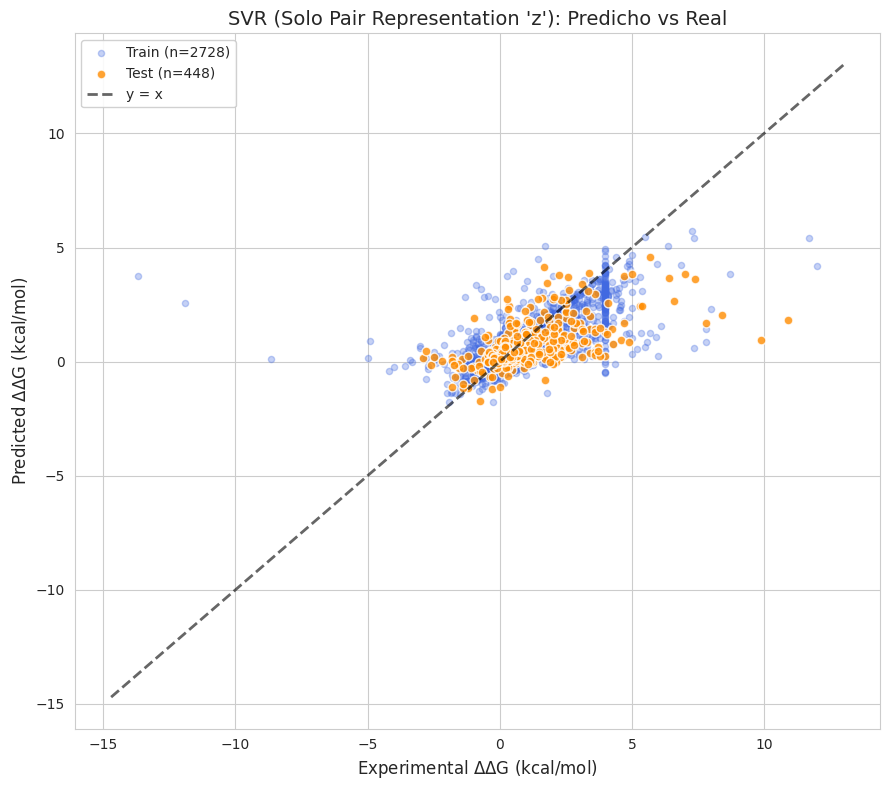

In [7]:
from scipy.stats import spearmanr, pearsonr
from sklearn.metrics import (
    mean_squared_error,
    roc_auc_score,
    matthews_corrcoef,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)


print("4. Generando predicciones...")
train_preds = model.predict(X_train_scaled)
test_preds = model.predict(X_test_scaled)

# Métricas de Regresión
rho, _ = spearmanr(y_test, test_preds)
r, _ = pearsonr(y_test, test_preds)
rmse = np.sqrt(mean_squared_error(y_test, test_preds))

print("\n========== RESULTADOS REGRESIÓN (SOLO 'z') ==========")
print(f"Spearman R : {rho:.3f}")
print(f"Pearson R  : {r:.3f}")
print(f"RMSE       : {rmse:.3f} kcal/mol")

# Métricas de Clasificación (Umbral -0.5)
UMBRAL = 0
y_test_bin = (y_test < UMBRAL).astype(int)
preds_bin = (test_preds < UMBRAL).astype(int)

auc_score = roc_auc_score(y_test_bin, -test_preds)
mcc_score = matthews_corrcoef(y_test_bin, preds_bin)
acc_score = accuracy_score(y_test_bin, preds_bin)
prec_score = precision_score(y_test_bin, preds_bin, zero_division=0)
rec_score = recall_score(y_test_bin, preds_bin, zero_division=0)
f1_score_val = f1_score(y_test_bin, preds_bin, zero_division=0)

tn, fp, fn, tp = confusion_matrix(y_test_bin, preds_bin).ravel()

print(f"\n========== RESULTADOS CLASIFICACIÓN (SVR, Umbral < {UMBRAL}) ==========")
print(f"Evaluado sobre: {len(X_test)} mutaciones")
print("-" * 50)
print(f"AUC        : {auc_score:.3f}")
print(f"MCC        : {mcc_score:.3f}")
print(f"Accuracy   : {acc_score:.3f}")
print(f"Precision  : {prec_score:.3f}")
print(f"Recall     : {rec_score:.3f}")
print(f"F1-score   : {f1_score_val:.3f}")

print("\n--- Matriz de Confusión ---")
print(f"TN: {tn} | FP: {fp}")
print(f"FN: {fn} | TP: {tp}")

print("\n--- Tabla estilo paper ---")
print(f"{'Model':<15} {'AUC':<6} {'MCC':<6} {'Acc':<6} {'F1':<6}")
print("-" * 45)
print(f"{'SVR (z-only)':<15} {auc_score:.3f} {mcc_score:.3f} {acc_score:.3f} {f1_score_val:.3f}")
print("===================================================================")

# =================================================================
# 6. GRÁFICO: PREDICHO VS REAL (Train y Test)
# =================================================================
plt.figure(figsize=(9, 8))
sns.set_style("whitegrid")

# Puntos de Train Original (azul)
# Usamos solo la primera mitad de las predicciones para no graficar los aumentados
num_train_orig = len(X_train)
plt.scatter(y_train, train_preds[:num_train_orig], 
            color='royalblue', alpha=0.3, s=20, label=f'Train (n={num_train_orig})')

# Puntos de Test (naranja)
plt.scatter(y_test, test_preds, 
            color='darkorange', alpha=0.8, s=40, edgecolors='white', label=f'Test (n={len(y_test)})')

# Línea de Predicción Perfecta
min_val = min(y_train.min(), y_test.min(), train_preds.min(), test_preds.min()) - 1
max_val = max(y_train.max(), y_test.max(), train_preds.max(), test_preds.max()) + 1
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, alpha=0.6, label='y = x')

plt.xlabel('Experimental $\Delta\Delta G$ (kcal/mol)', fontsize=12)
plt.ylabel('Predicted $\Delta\Delta G$ (kcal/mol)', fontsize=12)
plt.title("SVR (Solo Pair Representation 'z'): Predicho vs Real", fontsize=14)
plt.legend(loc='upper left', framealpha=0.9)

plt.tight_layout()
plt.show()

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# 1. Preparación de Tensores (usando tus datos ya escalados)
X_train_torch = torch.FloatTensor(X_train_scaled)
y_train_torch = torch.FloatTensor(y_train_final).view(-1, 1)
X_test_torch = torch.FloatTensor(X_test_scaled)
y_test_torch = torch.FloatTensor(y_test).view(-1, 1)

train_dataset = TensorDataset(X_train_torch, y_train_torch)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# 2. Definición de la Arquitectura del MLP
class ProteinMLP(nn.Module):
    def __init__(self, input_dim):
        super(ProteinMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
        
    def forward(self, x):
        return self.net(x)

input_dim = X_train_torch.shape[1]
mlp_model = ProteinMLP(input_dim)
criterion = nn.MSELoss()
optimizer = optim.Adam(mlp_model.parameters(), lr=0.001, weight_decay=1e-4)

# 3. Bucle de Entrenamiento
print(f"Entrenando MLP con entrada de dimensión {input_dim}...")
mlp_model.train()
epochs = 50

for epoch in range(epochs):
    epoch_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = mlp_model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss/len(train_loader):.4f}")

# 4. Evaluación
mlp_model.eval()
with torch.no_grad():
    y_pred_mlp = mlp_model(X_test_torch).numpy().flatten()

# Métricas de Regresión
spr_mlp = spearmanr(y_test, y_pred_mlp)[0]
pears_mlp = pearsonr(y_test, y_pred_mlp)[0]
rmse_mlp = np.sqrt(mean_squared_error(y_test, y_pred_mlp))

print("\n========== RESULTADOS MLP (SOLO 'z') ==========")
print(f"Spearman R : {spr_mlp:.3f}")
print(f"Pearson R  : {pears_mlp:.3f}")
print(f"RMSE        : {rmse_mlp:.3f} kcal/mol")

Entrenando MLP con entrada de dimensión 256...
Epoch [10/50], Loss: 1.0102
Epoch [20/50], Loss: 0.7851
Epoch [30/50], Loss: 0.5917
Epoch [40/50], Loss: 0.4790
Epoch [50/50], Loss: 0.4298

========== RESULTADOS MLP (SOLO 'z') ==========
Spearman R : 0.651
Pearson R  : 0.631
RMSE        : 1.317 kcal/mol


4. Generando predicciones con el MLP...

========== RESULTADOS REGRESIÓN (MLP - SOLO 'z') ==========
Spearman R : 0.651
Pearson R  : 0.631
RMSE       : 1.317 kcal/mol

========== RESULTADOS CLASIFICACIÓN (MLP, Umbral < 0) ==========
Evaluado sobre: 448 mutaciones
--------------------------------------------------
AUC        : 0.807
MCC        : 0.323
Accuracy   : 0.799
Precision  : 0.507
Recall     : 0.385
F1-score   : 0.438

--- Matriz de Confusión ---
TN: 323 | FP: 34
FN: 56 | TP: 35

--- Tabla estilo paper ---
Model           AUC    MCC    Acc    F1    
---------------------------------------------
MLP (z-only)    0.807 0.323 0.799 0.438


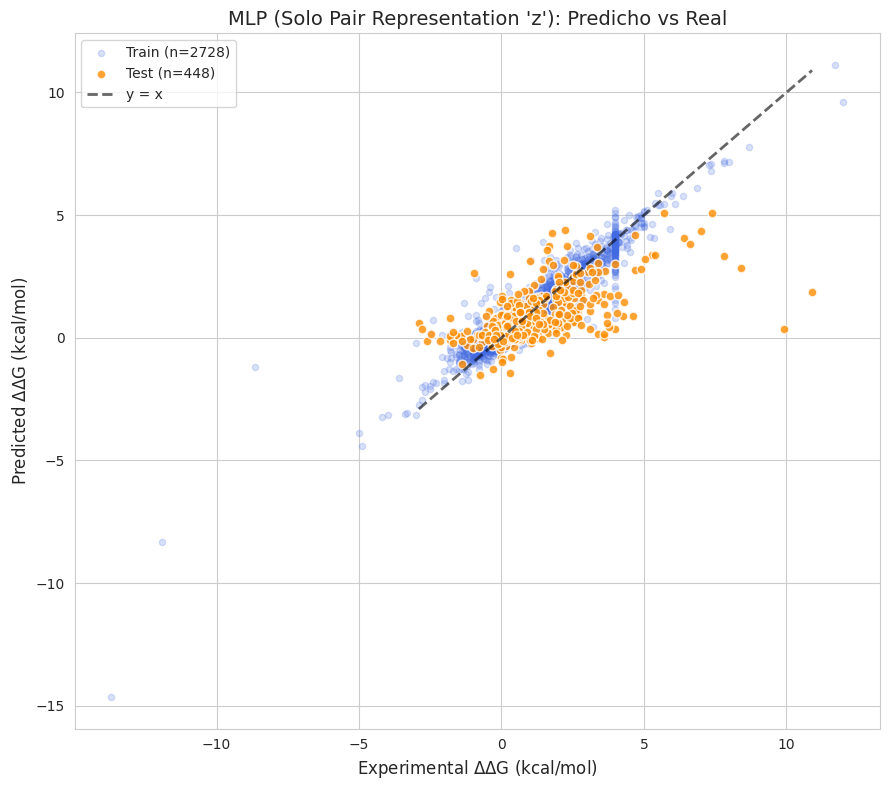

In [10]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, pearsonr
from sklearn.metrics import (
    mean_squared_error, roc_auc_score, matthews_corrcoef,
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)

# =================================================================
# 5. GENERACIÓN DE PREDICCIONES (MLP PyTorch)
# =================================================================
print("4. Generando predicciones con el MLP...")

# Ponemos el modelo en modo evaluación (desactiva Dropout)
mlp_model.eval()

with torch.no_grad():
    # Convertimos datos a Tensores
    X_train_tensor = torch.FloatTensor(X_train_scaled)
    X_test_tensor = torch.FloatTensor(X_test_scaled)
    
    # Inferencia
    train_preds = mlp_model(X_train_tensor).cpu().numpy().flatten()
    test_preds = mlp_model(X_test_tensor).cpu().numpy().flatten()

# Métricas de Regresión
rho, _ = spearmanr(y_test, test_preds)
r, _ = pearsonr(y_test, test_preds)
rmse = np.sqrt(mean_squared_error(y_test, test_preds))

print("\n========== RESULTADOS REGRESIÓN (MLP - SOLO 'z') ==========")
print(f"Spearman R : {rho:.3f}")
print(f"Pearson R  : {r:.3f}")
print(f"RMSE       : {rmse:.3f} kcal/mol")

# =================================================================
# 5b. CLASIFICACIÓN (Umbral estabilizador)
# =================================================================
UMBRAL = 0
y_test_bin = (y_test < UMBRAL).astype(int)
preds_bin = (test_preds < UMBRAL).astype(int)

# AUC usando el negativo de la predicción (a menor ddG predicho, mayor probabilidad de clase 1)
auc_score = roc_auc_score(y_test_bin, -test_preds)
mcc_score = matthews_corrcoef(y_test_bin, preds_bin)
acc_score = accuracy_score(y_test_bin, preds_bin)
prec_score = precision_score(y_test_bin, preds_bin, zero_division=0)
rec_score = recall_score(y_test_bin, preds_bin, zero_division=0)
f1_val = f1_score(y_test_bin, preds_bin, zero_division=0)

tn, fp, fn, tp = confusion_matrix(y_test_bin, preds_bin).ravel()

print(f"\n========== RESULTADOS CLASIFICACIÓN (MLP, Umbral < {UMBRAL}) ==========")
print(f"Evaluado sobre: {len(X_test)} mutaciones")
print("-" * 50)
print(f"AUC        : {auc_score:.3f}")
print(f"MCC        : {mcc_score:.3f}")
print(f"Accuracy   : {acc_score:.3f}")
print(f"Precision  : {prec_score:.3f}")
print(f"Recall     : {rec_score:.3f}")
print(f"F1-score   : {f1_val:.3f}")

print("\n--- Matriz de Confusión ---")
print(f"TN: {tn} | FP: {fp}")
print(f"FN: {fn} | TP: {tp}")

print("\n--- Tabla estilo paper ---")
print(f"{'Model':<15} {'AUC':<6} {'MCC':<6} {'Acc':<6} {'F1':<6}")
print("-" * 45)
print(f"{'MLP (z-only)':<15} {auc_score:.3f} {mcc_score:.3f} {acc_score:.3f} {f1_val:.3f}")
print("===================================================================")

# =================================================================
# 6. GRÁFICO: PREDICHO VS REAL
# =================================================================
plt.figure(figsize=(9, 8))
sns.set_style("whitegrid")

# Graficamos solo la mitad del train (el original, sin el aumentado invertido) para no saturar
num_train_orig = len(X_train)
plt.scatter(y_train[:num_train_orig], train_preds[:num_train_orig], 
            color='royalblue', alpha=0.2, s=20, label=f'Train (n={num_train_orig})')

plt.scatter(y_test, test_preds, 
            color='darkorange', alpha=0.8, s=40, edgecolors='white', label=f'Test (n={len(y_test)})')

# Línea y=x
combined_min = min(y_test.min(), test_preds.min())
combined_max = max(y_test.max(), test_preds.max())
plt.plot([combined_min, combined_max], [combined_min, combined_max], 'k--', lw=2, alpha=0.6, label='y = x')

plt.xlabel('Experimental $\Delta\Delta G$ (kcal/mol)', fontsize=12)
plt.ylabel('Predicted $\Delta\Delta G$ (kcal/mol)', fontsize=12)
plt.title("MLP (Solo Pair Representation 'z'): Predicho vs Real", fontsize=14)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
import os
import requests
import numpy as np
from Bio.PDB import PDBParser, DSSP
import warnings
from Bio import BiopythonWarning

warnings.simplefilter('ignore', BiopythonWarning)

class RealAKBExtractor:
    def __init__(self, pdb_dir="./alphafold_structures"):
        self.pdb_dir = pdb_dir
        if not os.path.exists(self.pdb_dir):
            os.makedirs(self.pdb_dir)
        self.akb_cache = {} # Cache para no re-descargar la misma proteína

    def fetch_alphafold_pdb(self, uniprot_id):
        """Descarga el PDB desde AlphaFold DB usando el UniProt ID."""
        pdb_path = os.path.join(self.pdb_dir, f"{uniprot_id}.pdb")
        
        if os.path.exists(pdb_path):
            return pdb_path # Ya lo tenemos en local

        # Consultar la API de AlphaFold
        url = f"https://alphafold.ebi.ac.uk/api/prediction/{uniprot_id}"
        response = requests.get(url)
        
        if response.status_code == 200:
            data = response.json()
            if data and len(data) > 0:
                pdb_url = data[0]['pdbUrl']
                # Descargar el archivo PDB
                pdb_data = requests.get(pdb_url).text
                with open(pdb_path, 'w') as f:
                    f.write(pdb_data)
                return pdb_path
        print(f"Advertencia: No se encontró estructura en AlphaFold para {uniprot_id}")
        return None

    def get_structure_features(self, uniprot_id):
        """Usa DSSP para extraer RSA y SS real de la estructura 3D."""
        if uniprot_id in self.akb_cache:
            return self.akb_cache[uniprot_id]

        pdb_path = self.fetch_alphafold_pdb(uniprot_id)
        if not pdb_path:
            return None # Fallback si no hay PDB

        try:
            parser = PDBParser()
            structure = parser.get_structure(uniprot_id, pdb_path)
            model = structure[0]
            
            # Ejecutar DSSP (Calcula solvent accessibility y secondary structure)
            # Nota: 'dssp' debe estar en el PATH del sistema operativo
            dssp = DSSP(model, pdb_path, dssp='dssp')
            
            features = {}
            for key in dssp.keys():
                # key es una tupla: (chain, res_id)
                res_num = key[1][1] - 1 # Ajustar a índice 0-based
                
                dssp_data = dssp[key]
                ss_raw = dssp_data[2] # H (Helix), B/E (Strand), T/S/C (Loop/Coil)
                rsa = dssp_data[3]    # Relative Solvent Accessibility

                # Agrupar Estructura Secundaria en 3 clases principales
                is_helix = 1.0 if ss_raw in ['H', 'G', 'I'] else 0.0
                is_strand = 1.0 if ss_raw in ['B', 'E'] else 0.0
                is_loop = 1.0 if ss_raw not in ['H', 'G', 'I', 'B', 'E'] else 0.0

                features[res_num] = {
                    'rsa': float(rsa),
                    'ss': [is_helix, is_strand, is_loop]
                }
            
            self.akb_cache[uniprot_id] = features
            return features
            
        except Exception as e:
            print(f"Error procesando DSSP para {uniprot_id}: {e}")
            return None

# ==========================================
# CÓMO USARLO EN TU BUCLE DE EXTRACCIÓN
# ==========================================

extractor = RealAKBExtractor()
window_size = 2

# Listas para el modelo
X_list, y_list, groups_list = [], [], []

print("Extrayendo datos estructurales reales y generando tensores...")
for i in range(len(dataset)):
    sample = dataset[i]
    uniprot_id = sample['wt_id']
    _, pos, _ = get_mutation_info(sample['mutation'])
    
    if pos is None: continue

    # 1. Obtener características reales de la estructura (RSA y SS)
    # Esto descargará el PDB la primera vez y lo guardará en caché
    struct_features = extractor.get_structure_features(uniprot_id)
    
    # Valores por defecto por si falla la descarga o DSSP
    rsa_val = 0.5
    ss_vector = [0.0, 0.0, 1.0] # Asumimos Loop por defecto
    conservation_val = 0.0 # Requiere PSI-BLAST local, lo dejamos en 0 de momento

    if struct_features and pos in struct_features:
        rsa_val = struct_features[pos]['rsa']
        ss_vector = struct_features[pos]['ss']

    # Vector AKB Real [RSA, Conservación, Hélice, Lámina, Loop]
    akb_features = np.array([rsa_val, conservation_val] + ss_vector)

    # 2. Construir la ventana de secuencias (como ya hablamos)
    L,_ , D = sample['wt_z'].shape
    def get_window_z(rep):
        context = []
        for offset in range(-window_size, window_size + 1):
            idx = pos + offset
            if 0 <= idx < L:
                context.append(rep[idx].mean(dim=0).numpy())
            else:
                context.append(np.zeros(D))
        return np.concatenate(context)

    wt_z_window = get_window_z(sample['wt_z'])
    mut_z_window = get_window_z(sample['mut_z'])

    # 3. Concatenar todo: (Contexto_WT + Contexto_MUT + Rasgos_Estructurales_Reales)
    full_vector = np.concatenate([wt_z_window, mut_z_window, akb_features])
    
    X_list.append(full_vector)
    y_list.append(sample['ddg'].item())
    groups_list.append(uniprot_id)

Extrayendo datos estructurales reales y generando tensores...
Error procesando DSSP para P06654: [Errno 2] No such file or directory: 'mkdssp'


ValueError: too many values to unpack (expected 2)